# Logistic Regression Binary Classification

This notebook implements a complete machine learning pipeline for binary classification of coronary artery stenosis using Logistic Regression.

## Execution Order:
1. **Imports**: Load all required libraries
2. **Load Dataset**: Import and prepare the raw data, create binary target
3. **Dropping dependent Features**: Remove derived variables
4. **Preprocessing**: Clean data, handle missing values, and prepare features
5. **Feature Selection**: Select most informative features
6. **SMOTE Oversampling**: Balance classes using synthetic oversampling
7. **Build Pipeline**: Train Logistic Regression classifier
8. **Evaluation**: Comprehensive evaluation metrics
9. **Overfitting Check**: Compare training vs. test performance
10. **Visualization**: ROC and Precision-Recall curves


## 1. Imports

This cell imports all necessary libraries for data manipulation, preprocessing, model training, and evaluation. Key libraries include:
- **pandas/numpy**: Data manipulation and numerical operations
- **sklearn**: Machine learning tools (preprocessing, feature selection, metrics, cross-validation)
- **sklearn.linear_model**: Logistic Regression classifier
- **imblearn**: SMOTE for handling class imbalance
- **matplotlib**: Visualization


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    auc,
    balanced_accuracy_score,
    classification_report,
    roc_curve,
    accuracy_score,
    precision_recall_curve,
    recall_score,
    average_precision_score
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SklearnPipeline
from imblearn.over_sampling import SMOTE


## 2. Load Dataset

This cell loads the CSV dataset and performs initial data preparation:
- Reads the CSV file with semicolon separator
- Removes features with more than 62.5% missing values
- Removes class 1 (non-significant stenosis) to create binary classification
- Automatically converts object columns that look numeric to appropriate data types
- Displays cleaned dataset shape


In [2]:
na_values = ["", " ", "NA", "N/A", "NULL"]
data = pd.read_csv("../data/T49.2_Sep2025_1_StGallen.csv", sep=";", na_values=na_values)

threshold = 0.625
data = data.loc[:, data.isnull().mean() < threshold]

binary_mode = True
if binary_mode:
    data = data[data["OUTCOME_3Kat_KHK"] != 1].reset_index(drop=True)

object_cols = data.select_dtypes(include="object").columns
numeric_like_cols = []
for col in object_cols:
    cleaned = (
        data[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    numeric_series = pd.to_numeric(cleaned, errors="coerce")
    if numeric_series.notna().mean() > 0.95:
        data[col] = numeric_series
        numeric_like_cols.append(col)

print(
    f"Converted {len(numeric_like_cols)} mostly-numeric columns: {numeric_like_cols}"
)
print(f"Cleaned dataset shape: {data.shape}")


Converted 6 mostly-numeric columns: ['Alter_0', 'BMI_0', 'hba1c0', 'TyG_Index_neu', 'crp0', 'Kreat0']
Cleaned dataset shape: (1678, 94)


/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_77004/316730222.py:2: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../data/T49.2_Sep2025_1_StGallen.csv", sep=";", na_values=na_values)


## 3. Dropping dependent Features

This cell removes dependent variables that are directly derived from other features. These features contain redundant information and can cause multicollinearity issues.


In [3]:
columns_to_drop = ["remnantCholesterol0_corr", "ldl0_mmol", "hdl0_mmol", "triglyc0_mmol", "cholest0_mmol", "LDL_0_apo_B_ratio", "BONE_KAT"]
data = data.drop(columns_to_drop, axis=1)
print(f"Dataset shape after dropping dependent features: {data.shape}")


Dataset shape after dropping dependent features: (1678, 87)


## 4. Preprocessing

This cell performs comprehensive data preprocessing:

**Feature Type Identification:**
- Identifies categorical and numerical features
- Automatically converts object columns that look numeric
- Handles manual categorical feature definitions

**Data Cleaning:**
- Removes highly correlated features (correlation > 0.95) to reduce redundancy
- Creates binary target: 0 = No Stenosis, 1 = Significant Stenosis

**Train/Test Split:**
- Splits data into 80% training and 20% test set
- Uses stratified split to maintain class distribution

**Preprocessing Pipeline:**
- **Categorical features**: Most frequent imputation + One-Hot Encoding
- **Numerical features**: Median imputation + Standard Scaling


In [4]:
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"].replace({2: 1})

manual_categorical_candidates = [
    "geschlecht",
    "currsmo0",
    "diabetes_ADA_final_0",
    "ANY_OPE",
    "ANY_OPO",
    "Osteoporos_inkl_Osteopenie_T_Wert_abhängig",
    "Osteoporose_T_Wert_abhängig"
]
resolved_categoricals = []
missing_manual = []
for candidate in manual_categorical_candidates:
    match = next((col for col in X.columns if col.lower() == candidate.lower()), None)
    if match:
        resolved_categoricals.append(match)
    else:
        missing_manual.append(candidate)
if missing_manual:
    print(f"Manual categorical columns not found: {missing_manual}")

categorical_features = sorted(dict.fromkeys(resolved_categoricals))

non_cat_object_cols = [
    col for col in X.columns if col not in categorical_features and X[col].dtype == "object"
]
forced_numeric = []
for col in non_cat_object_cols:
    cleaned = (
        X[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    converted = pd.to_numeric(cleaned, errors="coerce")
    X[col] = converted
    forced_numeric.append(col)
if forced_numeric:
    sample = forced_numeric[:5]
    print(
        f"Forced {len(forced_numeric)} object columns to numeric (sample: {sample})"
    )

numerical_features = [col for col in X.columns if col not in categorical_features]

if categorical_features:
    X[categorical_features] = X[categorical_features].astype(str)

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): sample -> {numerical_features[:5]}")

if len(numerical_features) > 0:
    X_num = X[numerical_features].select_dtypes(include=['float64', 'int64'])
    if len(X_num.columns) > 0:
        corr_matrix = X_num.corr().abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        to_remove = set()
        for column in upper_triangle.columns:
            high_corr = upper_triangle.index[upper_triangle[column] > 0.95].tolist()
            if high_corr:
                for col in high_corr:
                    if column not in to_remove:
                        to_remove.add(col)
        
        if len(to_remove) > 0:
            print(f"Removing {len(to_remove)} highly correlated features")
            X = X.drop(columns=list(to_remove), errors='ignore')
            numerical_features = [f for f in numerical_features if f not in to_remove]

print(f"After cleaning - Numerical: {len(numerical_features)}, Categorical: {len(categorical_features)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_preprocessor = SklearnPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

num_preprocessor = SklearnPipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_preprocessor, categorical_features),
        ("num", num_preprocessor, numerical_features),
    ]
)


Forced 48 object columns to numeric (sample: ['waist_0', 'WHR_0', 'Lp_a_0', 'insulm0', 'HOMA_Index_IR_0'])
Categorical features (7): ['ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'currsmo0', 'diabetes_ADA_final_0', 'geschlecht']
Numerical features (79): sample -> ['Alter_0', 'waist_0', 'WHR_0', 'BMI_0', 'RR_syst_0']
Removing 1 highly correlated features
After cleaning - Numerical: 78, Categorical: 7


## 5. Feature Selection

This cell selects the most informative features using mutual information:
- Uses SelectKBest with mutual_info_classif to rank features
- Selects top k=50 features to reduce dimensionality
- Fits selector on training data and transforms both training and test sets


In [5]:
np.random.seed(42)

X_train_transformed = preprocessor.fit_transform(X_train, y_train)
X_test_transformed = preprocessor.transform(X_test)

selector = SelectKBest(mutual_info_classif, k=50)
X_train_selected = selector.fit_transform(X_train_transformed, y_train)
X_test_selected = selector.transform(X_test_transformed)

print(f"Selected {X_train_selected.shape[1]} features out of {X_train_transformed.shape[1]}")


Selected 50 features out of 96


## 6. SMOTE Oversampling

This cell applies SMOTE (Synthetic Minority Oversampling Technique) to balance the classes:
- Generates synthetic samples for the minority class
- Uses k_neighbors=3 to reduce overfitting
- Balances the training set before model training


In [6]:
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_selected, y_train)

print(f"Class distribution before SMOTE:")
print(f"  No Stenosis (Class 0): {(y_train == 0).sum()} samples ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Significant Stenosis (Class 1): {(y_train == 1).sum()} samples ({(y_train == 1).mean()*100:.1f}%)")
print(f"\nClass distribution after SMOTE:")
print(f"  No Stenosis (Class 0): {(y_train_balanced == 0).sum()} samples ({(y_train_balanced == 0).mean()*100:.1f}%)")
print(f"  Significant Stenosis (Class 1): {(y_train_balanced == 1).sum()} samples ({(y_train_balanced == 1).mean()*100:.1f}%)")
print(f"\nTraining set size: {X_train_balanced.shape[0]} samples, {X_train_balanced.shape[1]} features")


Class distribution before SMOTE:
  No Stenosis (Class 0): 290 samples (21.6%)
  Significant Stenosis (Class 1): 1052 samples (78.4%)

Class distribution after SMOTE:
  No Stenosis (Class 0): 1052 samples (50.0%)
  Significant Stenosis (Class 1): 1052 samples (50.0%)

Training set size: 2104 samples, 50 features


## 7. Build Pipeline

This cell builds and trains the Logistic Regression model:

**Process:**
1. Creates Logistic Regression classifier with balanced class weights
2. Performs 5-fold cross-validation to assess model performance
3. Trains final model on balanced training set
4. Makes predictions on test set

**Hyperparameters:**
- `class_weight='balanced'`: Automatically adjusts weights inversely proportional to class frequencies
- `max_iter=1000`: Maximum iterations for convergence
- `solver='lbfgs'`: Limited-memory BFGS solver, good for small datasets


In [7]:
model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=cv_strategy, scoring='balanced_accuracy')

model.fit(X_train_balanced, y_train_balanced)

y_pred = model.predict(X_test_selected)
y_proba = model.predict_proba(X_test_selected)

print(f"Mean Cross-Validation Balanced Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


Mean Cross-Validation Balanced Accuracy: 0.7576 (+/- 0.0346)


## 8. Evaluation

This cell provides a comprehensive evaluation of the model's performance on the test set.

**Metrics Reported:**
- **Recall for Class 1** (Significant Stenosis): Most important metric for clinical application
- **Balanced Accuracy**: Average recall across both classes (better for imbalanced data)
- **Classification Report**: Per-class precision, recall, F1-score, and support
- **Cross-Validation Score**: Mean balanced accuracy from 5-fold CV


In [8]:
report = classification_report(y_test, y_pred, target_names=["No Stenosis", "Significant Stenosis"])

balanced_acc = balanced_accuracy_score(y_test, y_pred)
recall_class1 = recall_score(y_test, y_pred, pos_label=1)

print("=" * 80)
print("MODEL EVALUATION - Prioritizing Recall for Significant Stenosis (Class 1)")
print("=" * 80)
print(f"\nTest Recall (Significant Stenosis): {recall_class1:.4f}")
print(f"Test Balanced Accuracy: {balanced_acc:.4f}")
print(f"Mean Cross-Validation Balanced Accuracy: {cv_scores.mean():.4f}")
print("\nClassification Report:")
print(report)


MODEL EVALUATION - Prioritizing Recall for Significant Stenosis (Class 1)

Test Recall (Significant Stenosis): 0.6996
Test Balanced Accuracy: 0.6991
Mean Cross-Validation Balanced Accuracy: 0.7576

Classification Report:
                      precision    recall  f1-score   support

         No Stenosis       0.39      0.70      0.50        73
Significant Stenosis       0.89      0.70      0.78       263

            accuracy                           0.70       336
           macro avg       0.64      0.70      0.64       336
        weighted avg       0.78      0.70      0.72       336



## 9. Overfitting Check

This cell compares model performance on training vs. test data to detect overfitting. A well-generalizing model should have similar performance on both sets.

**Metrics Compared:**
- **Recall for Class 1** (Significant Stenosis): Most important metric for clinical application
- **Balanced Accuracy**: Average recall across both classes
- **Regular Accuracy**: Overall classification accuracy

**Interpretation:**
- Small gap (< 0.10): Good generalization
- Moderate gap (0.10-0.15): Some overfitting, acceptable
- Large gap (> 0.15): Significant overfitting, model may not generalize well


In [9]:
y_pred_train = model.predict(X_train_balanced)
y_pred_test = y_pred

train_recall_class1 = recall_score(y_train_balanced, y_pred_train, pos_label=1)
test_recall_class1 = recall_score(y_test, y_pred_test, pos_label=1)

train_bal_acc = balanced_accuracy_score(y_train_balanced, y_pred_train)
test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)

train_acc = accuracy_score(y_train_balanced, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("=" * 80)
print("OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 1)")
print("=" * 80)
print(f"\nRecall (Significant Stenosis):")
print(f"  Training: {train_recall_class1:.4f}")
print(f"  Test:     {test_recall_class1:.4f}")
print(f"  Gap:      {train_recall_class1 - test_recall_class1:.4f}")
print(f"\nBalanced Accuracy:")
print(f"  Training: {train_bal_acc:.4f}")
print(f"  Test:     {test_bal_acc:.4f}")
print(f"  Gap:      {train_bal_acc - test_bal_acc:.4f}")
print(f"\nRegular Accuracy:")
print(f"  Training: {train_acc:.4f}")
print(f"  Test:     {test_acc:.4f}")
print(f"  Gap:      {train_acc - test_acc:.4f}")

gap_recall = train_recall_class1 - test_recall_class1
gap_bal = train_bal_acc - test_bal_acc
gap_acc = train_acc - test_acc

if gap_recall > 0.15 or gap_bal > 0.15:
    print("\nWARNING: Large gap detected - model may be overfitting!")
    print("   Consider: stronger regularization, fewer features, or simpler model")
elif gap_recall > 0.10 or gap_bal > 0.10:
    print("\nCAUTION: Moderate gap detected - monitor for overfitting")
else:
    print("\nModel shows good generalization (small gap between train/test)")
    print(f"  Recall gap: {gap_recall:.4f} (good)")
    print(f"  Balanced accuracy gap: {gap_bal:.4f} (good)")


OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 1)

Recall (Significant Stenosis):
  Training: 0.7567
  Test:     0.6996
  Gap:      0.0570

Balanced Accuracy:
  Training: 0.7676
  Test:     0.6991
  Gap:      0.0685

Regular Accuracy:
  Training: 0.7676
  Test:     0.6994
  Gap:      0.0682

Model shows good generalization (small gap between train/test)
  Recall gap: 0.0570 (good)
  Balanced accuracy gap: 0.0685 (good)


## 10. Visualization

This cell visualizes model performance using:
- **Confusion Matrix**: Shows classification results for both classes
- **ROC Curve**: Trade-off between True Positive Rate and False Positive Rate with AUC score
- **Precision-Recall Curve**: Trade-off between precision and recall, more informative for imbalanced datasets


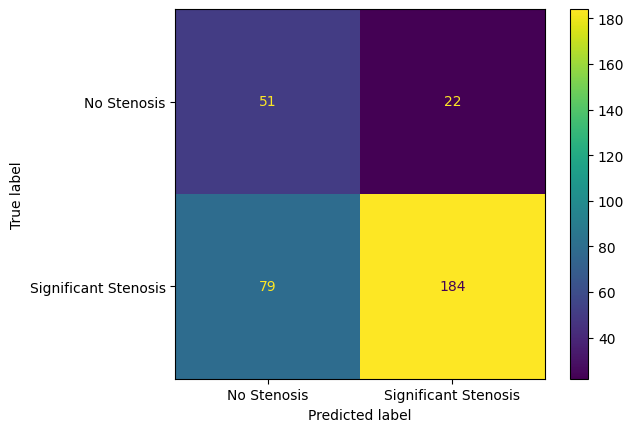

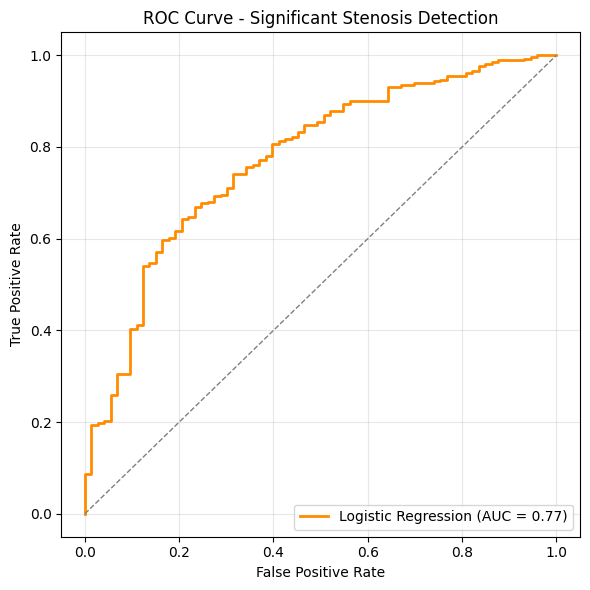

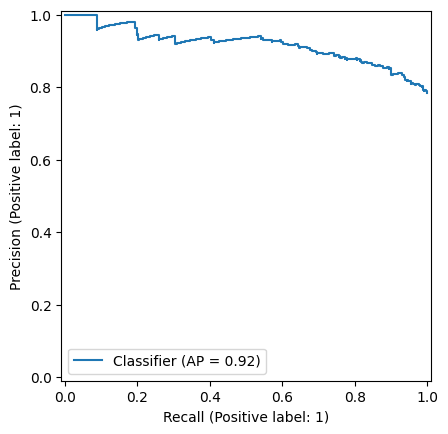

In [10]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No Stenosis", "Significant Stenosis"])

y_prob = y_proba[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Significant Stenosis Detection")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_prob)
